In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
# pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_112025_42s' # to specify the version of the data

Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

DTI=np.zeros((42, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC



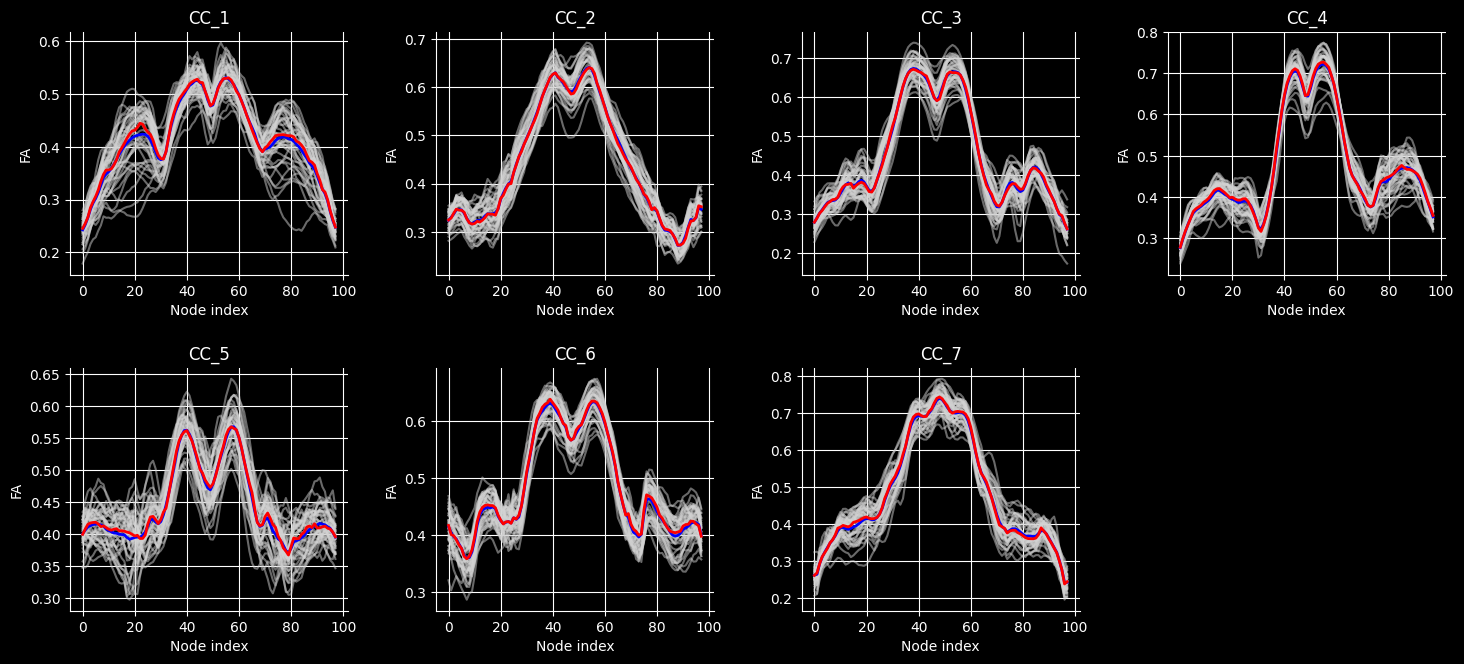

In [2]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



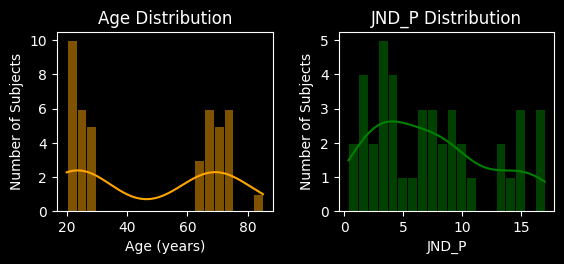

In [3]:
 # target var

import seaborn as sns

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


test of Regression models with DTI data on CC6

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values
age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']

Aging_INDICES



,sub,age,group,JND_P,group_O,group_Y,JND_group
0,sub-01,25,Y,9.5600,0.0,1.0,1
1,sub-02,27,Y,6.6900,0.0,1.0,0
2,sub-03,28,Y,12.9200,0.0,1.0,1
3,sub-05,21,Y,1.9500,0.0,1.0,0
4,sub-06,25,Y,2.5400,0.0,1.0,0
5,sub-08,67,O,4.4800,1.0,0.0,0
6,sub-09,73,O,9.6300,1.0,0.0,1
7,sub-10,64,O,7.2700,1.0,0.0,1
8,sub-11,21,Y,1.6200,0.0,1.0,0
9,sub-12,21,Y,3.6800,0.0,1.0,0


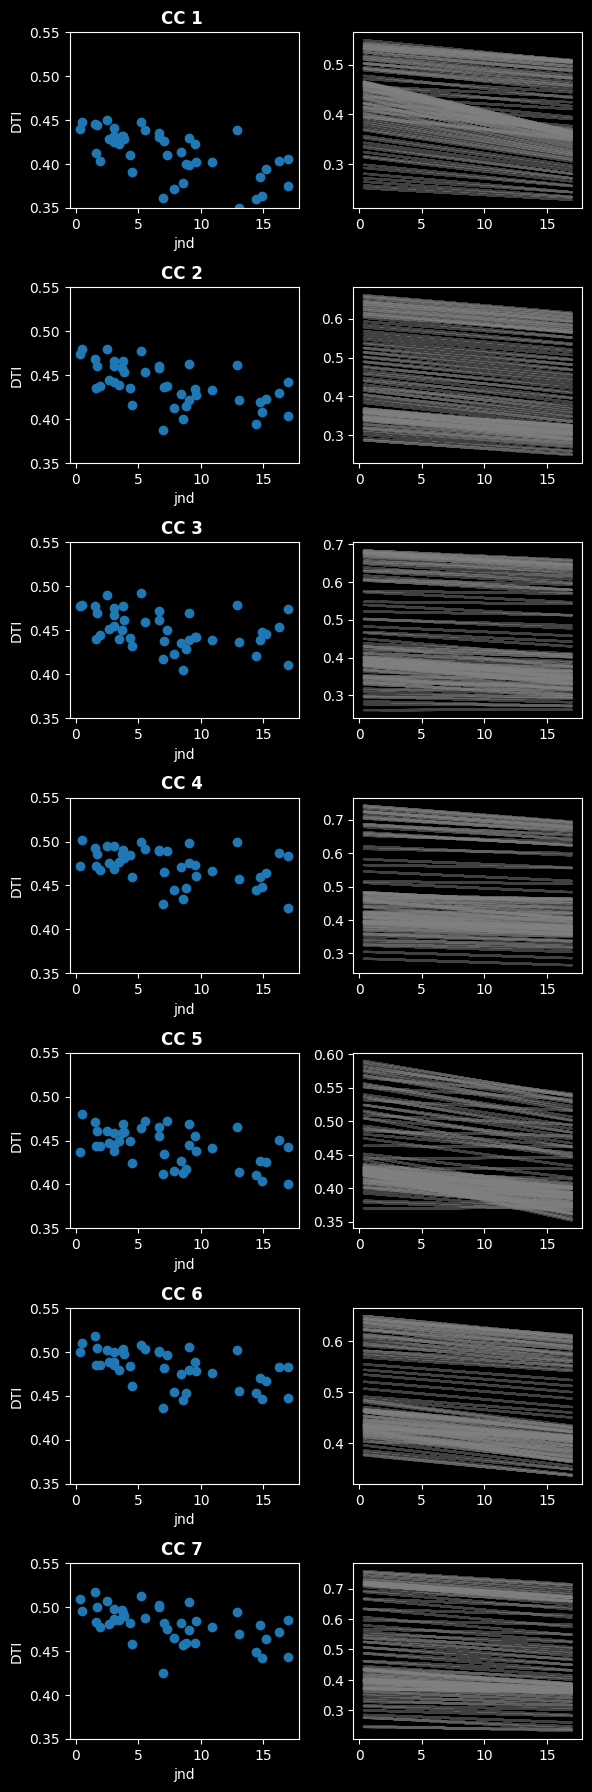

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(6, 18))

X = jnd.reshape(-1, 1)           # Target (dependent variable)

for CC in range(1,8):


    axs[CC-1,0].scatter(X, np.mean(DTI[:, :, CC-1], axis=1))
    axs[CC-1,0].set_ylim(0.35,0.55)

    # Extract the column of interest from DTI
    for i in range(98):
        y = DTI[:, i, CC-1].reshape(-1, 1)  # Features (independent variable)

        # Create and fit the linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Retrieve the results
        slope = model.coef_[0][0]
        intercept = model.intercept_[0]
        r_squared = model.score(X, y)

        # print(f"Slope: {slope:.4f}")
        # print(f"Intercept: {intercept:.4f}")
        # print(f"R²: {r_squared:.4f}")

        # Plot the results
        # axs.scatter(X, y, alpha=0.5, label='Data')
        axs[CC-1,1].plot(X, model.predict(X), color='grey',alpha=0.5)
        axs[CC-1,0].set_title(f'CC {CC} ',fontweight='bold')
        axs[CC-1,0].set_ylabel('DTI')
        axs[CC-1,0].set_xlabel('jnd')
        

    
    plt.tight_layout(pad=1)
    

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


slopesall=[]
R_squaredsall=[]
interceptsall=[]

for CC in range(1,8):

    slopes = []
    R_squareds = []
    intercepts = []
    # Extract the column of interest from DTI
    for i in range(98):
        y = DTI[:, i, CC-1].reshape(-1, 1)  # Features (independent variable)

        # Create and fit the linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Retrieve the results
        slope = model.coef_[0][0]
        intercept = model.intercept_[0]
        r_squared = model.score(X, y)
        slopes.append(slope)
        R_squareds.append(r_squared)
        intercepts.append(intercept)

    slopes_array=np.array(slopes)
    R_squareds_array=np.array(R_squareds)
    intercepts_array=np.array(intercepts)

    slopesall.append(slopes_array)
    R_squaredsall.append(R_squareds_array)
    interceptsall.append(intercepts_array)
    



Text(0.5, 0, 'Node Index')

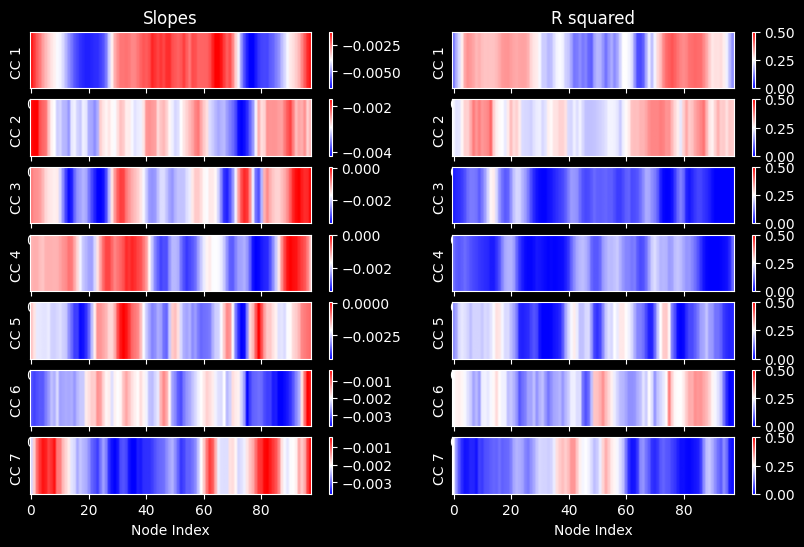

In [7]:

fig,axs=plt.subplots(nrows=7, ncols=2, figsize=(10, 6))
for CC in range(1,8):
    pos=axs[CC-1,0].imshow(slopesall[CC-1].reshape(-1,1).T, cmap='bwr', aspect='auto')
    axs[CC-1,0].set_yticks([])
    axs[CC-1,0].set_ylabel(f'CC {CC} ')
    fig.colorbar(pos,ax=axs[CC-1,0], orientation='vertical')

    pos2=axs[CC-1,1].imshow(np.abs(R_squaredsall[CC-1]).reshape(-1,1).T, cmap='bwr', aspect='auto', vmin=0, vmax=0.5)
    axs[CC-1,1].set_yticks([])
    axs[CC-1,1].set_ylabel(f'CC {CC} ')
    fig.colorbar(pos2,ax=axs[CC-1,1], orientation='vertical') 
    


axs[0,0].set_title('Slopes')
axs[0,1].set_title('R squared')
axs[6,0].set_xlabel('Node Index')
axs[6,1].set_xlabel('Node Index')

Text(0.5, 1.0, 'CC vs target R squared')

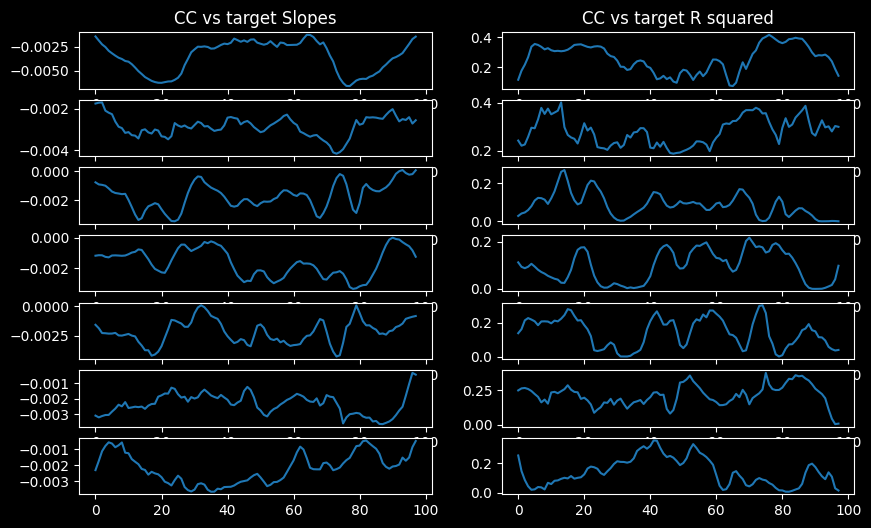

In [8]:
x=np.arange(98)

fig,axs=plt.subplots(nrows=7, ncols=2, figsize=(10, 6))
for CC in range(1,8):
    axs[CC-1,0].plot(x,slopesall[CC-1])
    axs[CC-1, 1].plot(x,R_squaredsall[CC-1])

axs[0,0].set_title(f'CC vs target Slopes')
axs[0,1].set_title(f'CC vs target R squared')



Feature selection for each CC

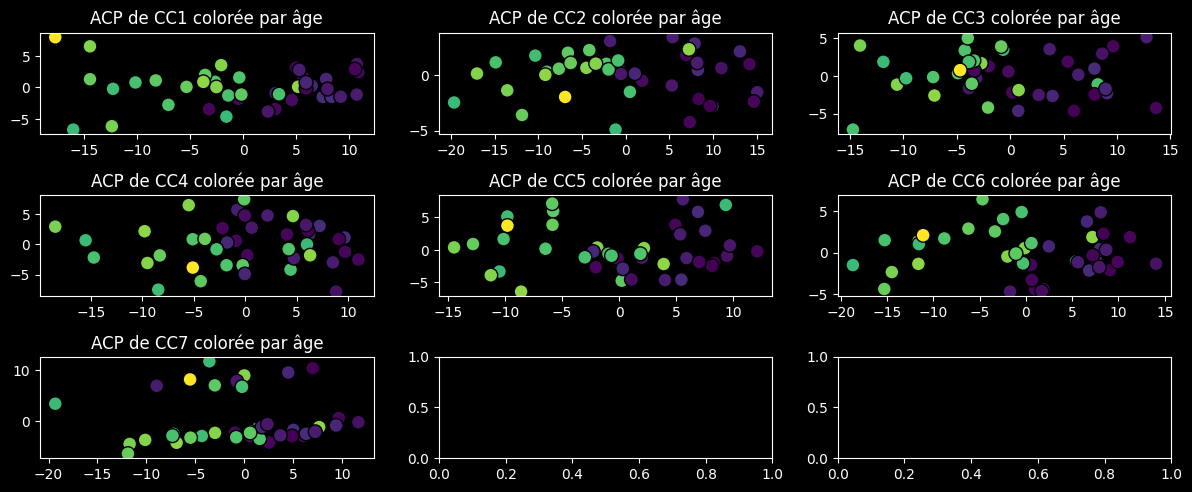

In [9]:
y=age       # Target (dependent variable)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



fig, ax = plt.subplots(3, 3, figsize=(12, 5))
ax = ax.flatten()

for cc in range(7):
     
     X = pd.DataFrame(DTI[:,:,cc])

     scaler = StandardScaler()
     X_scaled = scaler.fit_transform(X)

     pca = PCA(n_components=2)  # On garde 2 composantes pour la visualisation
     X_pca = pca.fit_transform(X_scaled)

     scatter = ax[cc].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', s=100)
     ax[cc].set_xlabel('')
     ax[cc].set_ylabel('')
     ax[cc].set_title(f'ACP de CC{cc+1} colorée par âge')


plt.tight_layout(pad=1.0  )


Feat selection with ridge regression

CC1 Best features (importance > 85% max): [13 14 15 16 17 18 19]
CC2 Best features (importance > 85% max): [ 9 10 12 25 26 69 70 71 72 73 74 75]
CC3 Best features (importance > 85% max): [13 14 23 24 25 41 42 43 66 67 68]
CC4 Best features (importance > 85% max): [77 78 79]
CC5 Best features (importance > 85% max): [72 73 74]
CC6 Best features (importance > 85% max): [75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90]
CC7 Best features (importance > 85% max): [16 17 18 22 23 24 25 29 30 32 73]


[array([13, 14, 15, 16, 17, 18, 19]),
 array([ 9, 10, 12, 25, 26, 69, 70, 71, 72, 73, 74, 75]),
 array([13, 14, 23, 24, 25, 41, 42, 43, 66, 67, 68]),
 array([77, 78, 79]),
 array([72, 73, 74]),
 array([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90]),
 array([16, 17, 18, 22, 23, 24, 25, 29, 30, 32, 73])]

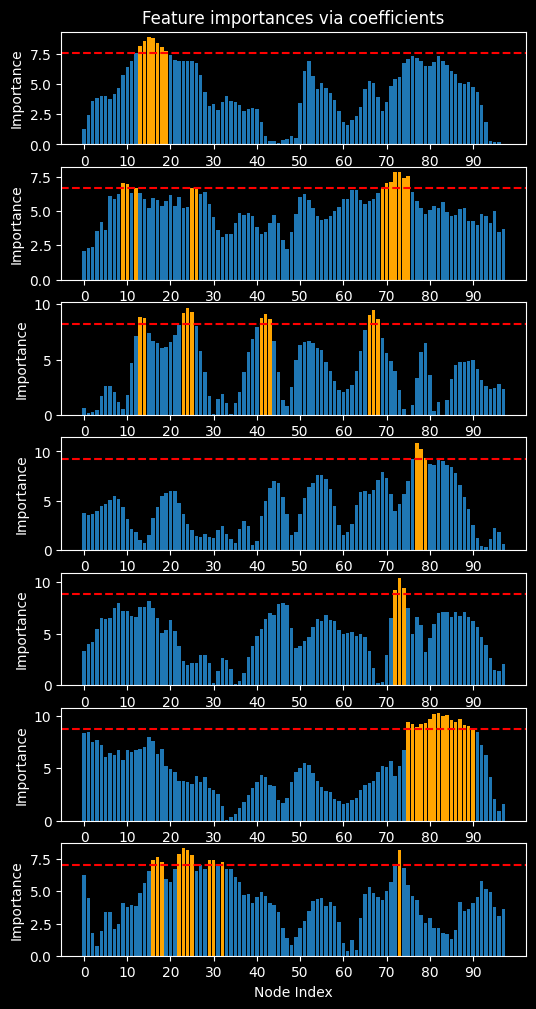

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import RidgeCV

thresholdpercent = 0.85



y=age       # Target (dependent variable)


figure, axs = plt.subplots(7, 1, figsize=(6,12))
best_features_all_ridge = []
for cc in range(7):
    X=DTI[:,:,cc]  # Features (independent variable)

    feature_names=np.array([f'{i}' for i in range(98)])
    feature=np.arange(98)

    ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
    importance = np.abs(ridge.coef_)
    ax = axs[cc]
    ax.bar(height=importance, x=feature_names)
    ax.set_xticks(range(0,98,10))
    ax.axhline(np.max(importance)*thresholdpercent, color='red', linestyle='--')
    ax.set_xlabel('Node Index')
    ax.set_ylabel('Importance')

    threshold = np.max(importance)*thresholdpercent

    importance_plus=np.where(importance>threshold)
    ax.bar(height=importance[importance_plus], x=feature_names[importance_plus], color='orange')

    best_features = feature[importance > threshold]
    print(f'CC{cc+1} Best features (importance > {int(thresholdpercent*100)}% max): {best_features}')
    best_features_all_ridge.append(best_features)
axs[0].set_title("Feature importances via coefficients")



best_features_all_ridge


Voting regression 

Random state: 6
MAE: 3.4074875706181467
MAE: 2.3782197711292428
MAE: 2.7229241574706116
MAE: 2.6462657615942615
MAE: 4.493556100394801
MAE: 2.748866682198747
MAE: 1.8242234350606679


array([9.63  , 1.67  , 0.37  , 5.5027, 9.07  ])

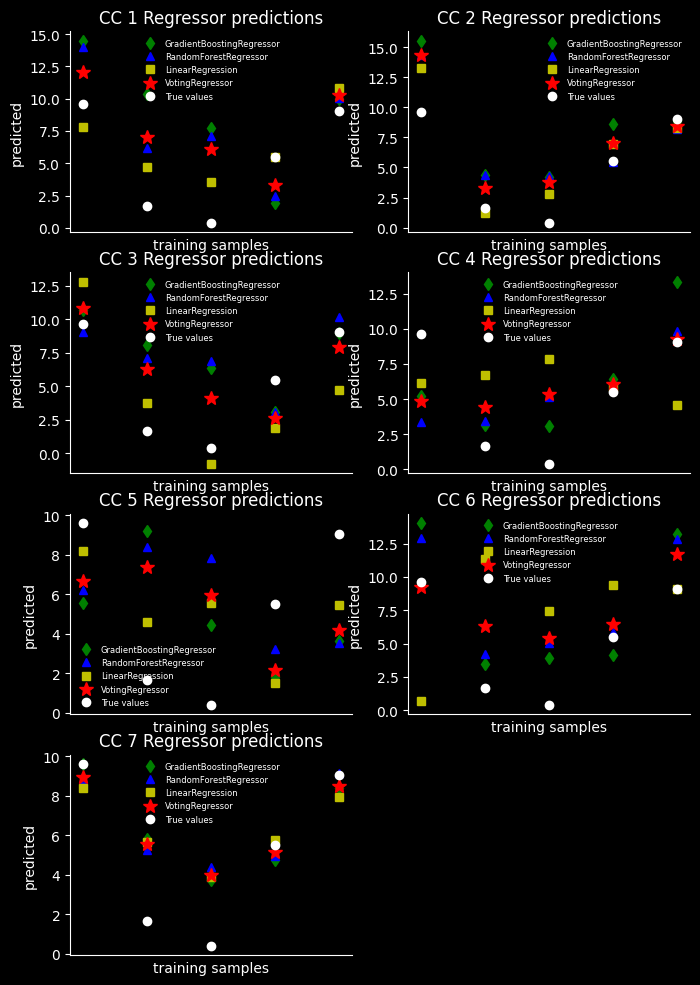

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


select_feature=best_features_all_ridge
y=jnd       # Features (independent variable)

figure, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 12)
                           )

axs = axs.flatten()
random_state=np.random.randint(0,100)
print("Random state:", random_state)
for cc in range(0,7):
    X=DTI[:,select_feature[cc],cc]    
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
         # Target (dependent variable)
# Train classifiers
    reg1 = GradientBoostingRegressor(random_state=1)
    reg2 = RandomForestRegressor(random_state=1)
    reg3 = LinearRegression()


    reg1.fit(X_train_scaled, y_train)
    reg2.fit(X_train_scaled, y_train)
    reg3.fit(X_train_scaled, y_train)

    ereg = VotingRegressor([("gb", reg1), ("rf", reg2), ("lr", reg3)])
    ereg.fit(X_train_scaled, y_train)


    pred1 = reg1.predict(X_test_scaled)
    pred2 = reg2.predict(X_test_scaled)
    pred3 = reg3.predict(X_test_scaled)
    pred4 = ereg.predict(X_test_scaled)
    # print("r2_score:", r2_score(y_test, pred4))
    print("MAE:", mean_absolute_error(y_test, pred4))
    axs[cc].plot(pred1, "gd", label="GradientBoostingRegressor")
    axs[cc].plot(pred2, "b^", label="RandomForestRegressor")
    axs[cc].plot(pred3, "ys", label="LinearRegression")
    axs[cc].plot(pred4, "r*", ms=10, label="VotingRegressor")
    axs[cc].plot(y_test, "wo", label="True values")
    axs[cc].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axs[cc].set_ylabel("predicted")
    axs[cc].set_xlabel("training samples")
    axs[cc].legend(loc="best", fontsize=6, frameon=False)
    axs[cc].set_title(f"CC {cc+1} Regressor predictions")
    axs[cc].spines['top'].set_visible(False)
    axs[cc].spines['right'].set_visible(False)

axs[7].axis('off')
y_test

Random state: 4
MAE: 2.121470508178926
MAE: 1.8553747281618052
MAE: 2.464478655938229
MAE: 2.9875577634647934
MAE: 3.323142099443929
MAE: 2.4951350894227096
MAE: 2.098171343941927


array([8.55  , 5.5027, 2.54  , 6.68  , 4.37  ])

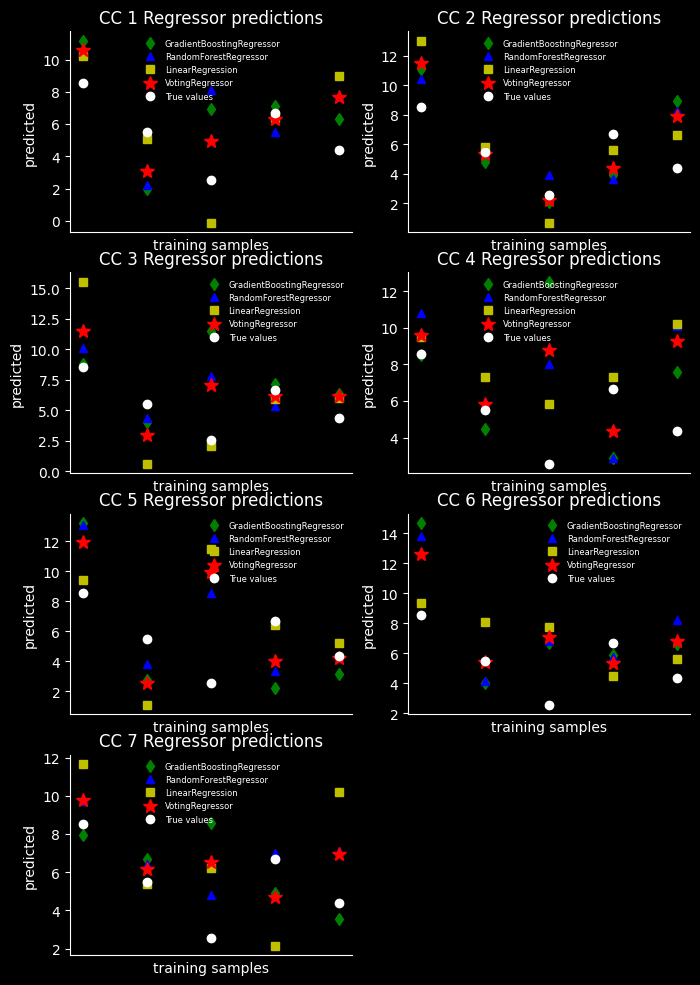

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


select_feature=best_features_all_ridge
y=jnd       # Features (independent variable)

figure, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 12)
                           )

axs = axs.flatten()
random_state=np.random.randint(0,100)
print("Random state:", random_state)
for cc in range(0,7):
    X=DTI[:,select_feature[cc],cc]    
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
         # Target (dependent variable)
# Train classifiers
    reg1 = GradientBoostingRegressor(random_state=1)
    reg2 = RandomForestRegressor(random_state=1)
    reg3 = LinearRegression()


    reg1.fit(X_train_scaled, y_train)
    reg2.fit(X_train_scaled, y_train)
    reg3.fit(X_train_scaled, y_train)

    ereg = VotingRegressor([("gb", reg1), ("rf", reg2), ("lr", reg3)])
    ereg.fit(X_train_scaled, y_train)


    pred1 = reg1.predict(X_test_scaled)
    pred2 = reg2.predict(X_test_scaled)
    pred3 = reg3.predict(X_test_scaled)
    pred4 = ereg.predict(X_test_scaled)
    # print("r2_score:", r2_score(y_test, pred4))
    print("MAE:", mean_absolute_error(y_test, pred4))
    axs[cc].plot(pred1, "gd", label="GradientBoostingRegressor")
    axs[cc].plot(pred2, "b^", label="RandomForestRegressor")
    axs[cc].plot(pred3, "ys", label="LinearRegression")
    axs[cc].plot(pred4, "r*", ms=10, label="VotingRegressor")
    axs[cc].plot(y_test, "wo", label="True values")
    axs[cc].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axs[cc].set_ylabel("predicted")
    axs[cc].set_xlabel("training samples")
    axs[cc].legend(loc="best", fontsize=6, frameon=False)
    axs[cc].set_title(f"CC {cc+1} Regressor predictions")
    axs[cc].spines['top'].set_visible(False)
    axs[cc].spines['right'].set_visible(False)

axs[7].axis('off')
y_test

Select K best

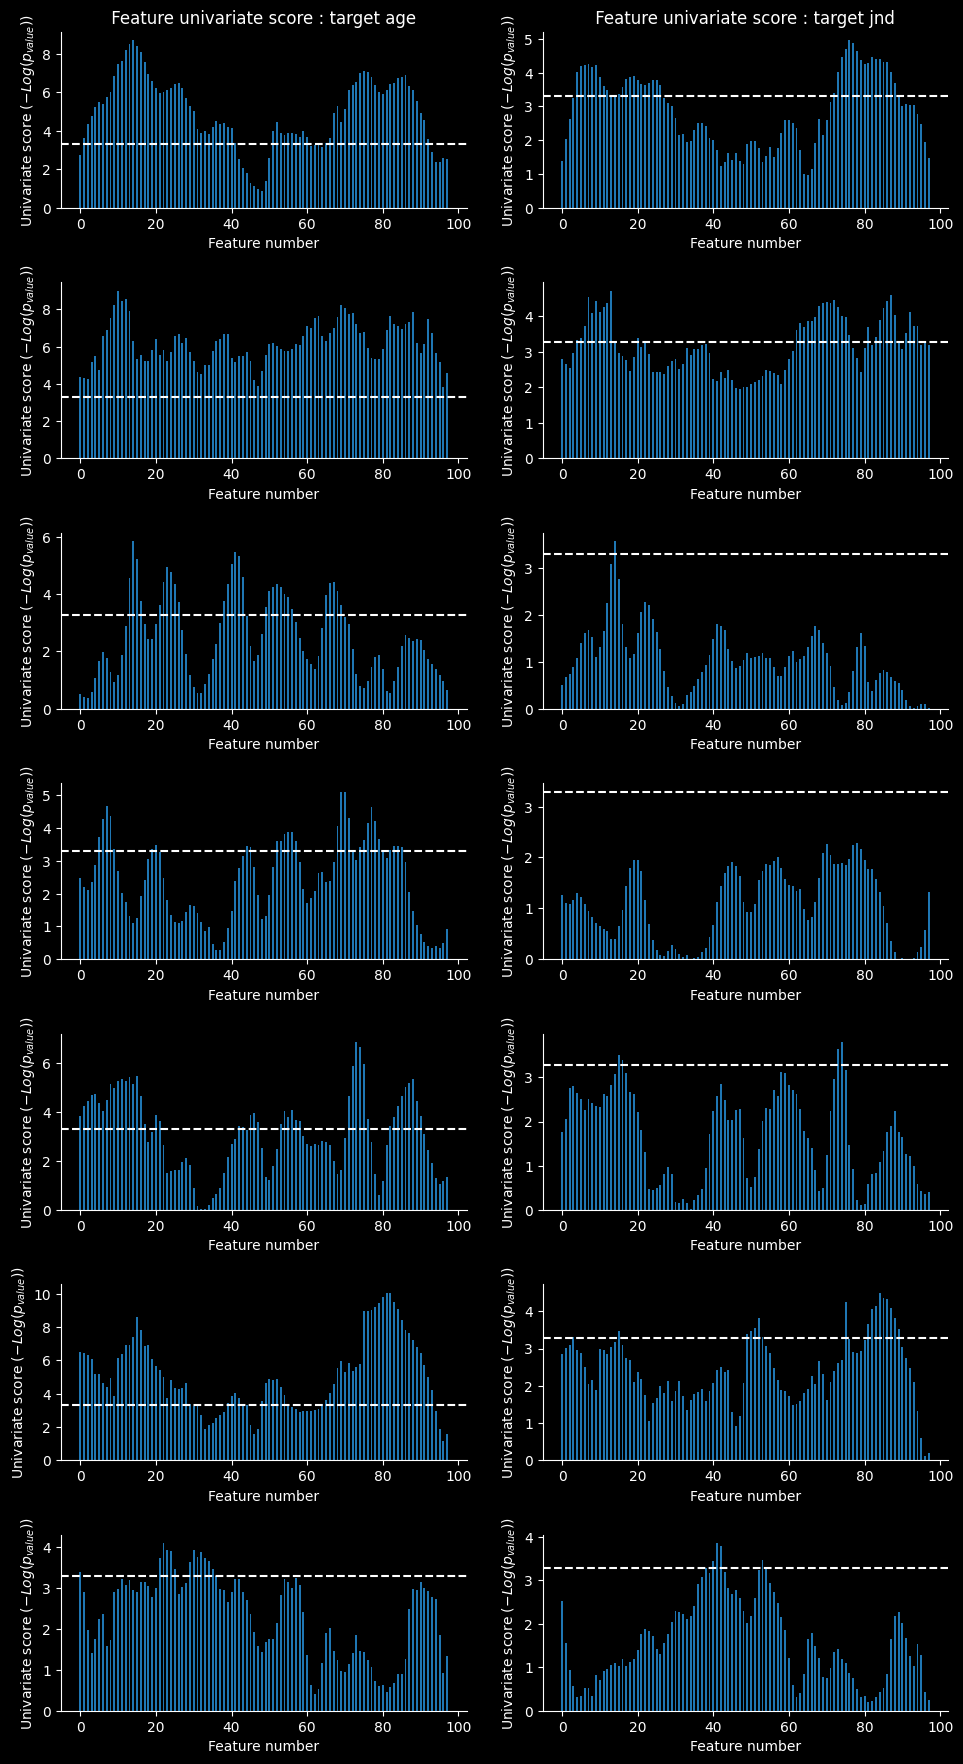

In [13]:
from sklearn.feature_selection import SelectKBest, f_regression


target=['age', 'jnd']
figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(10, 18))

for t in target:
    if t=='age':
        y=age
        axsy=0
    elif t=='jnd':
        y=jnd
        axsy=1

    for cc in range(7):

        X=DTI[:,:,cc]     # Features (independent variable)
            
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)


        selector = SelectKBest(f_regression)
        selector.fit(X_train, y_train)
        scores = -np.log10(selector.pvalues_)
        # scores /= scores.max()


        X_indices = np.arange(X.shape[-1])
        axs[cc, axsy].bar(X_indices, scores, width=0.5)
        axs[cc, axsy].axhline(-np.log10(0.05/98), color='w', linestyle='--')

        axs[cc, axsy].set_xlabel("Feature number")
        axs[cc, axsy].set_ylabel(r"Univariate score ($-Log(p_{value})$)")
        axs[cc, axsy].spines['top'].set_visible(False)
        axs[cc, axsy].spines['right'].set_visible(False)
    axs[0, axsy].set_title(f' Feature univariate score : target {t} ')

plt.tight_layout(pad=2.0)


RFE coupled with SVR or Log Regr.

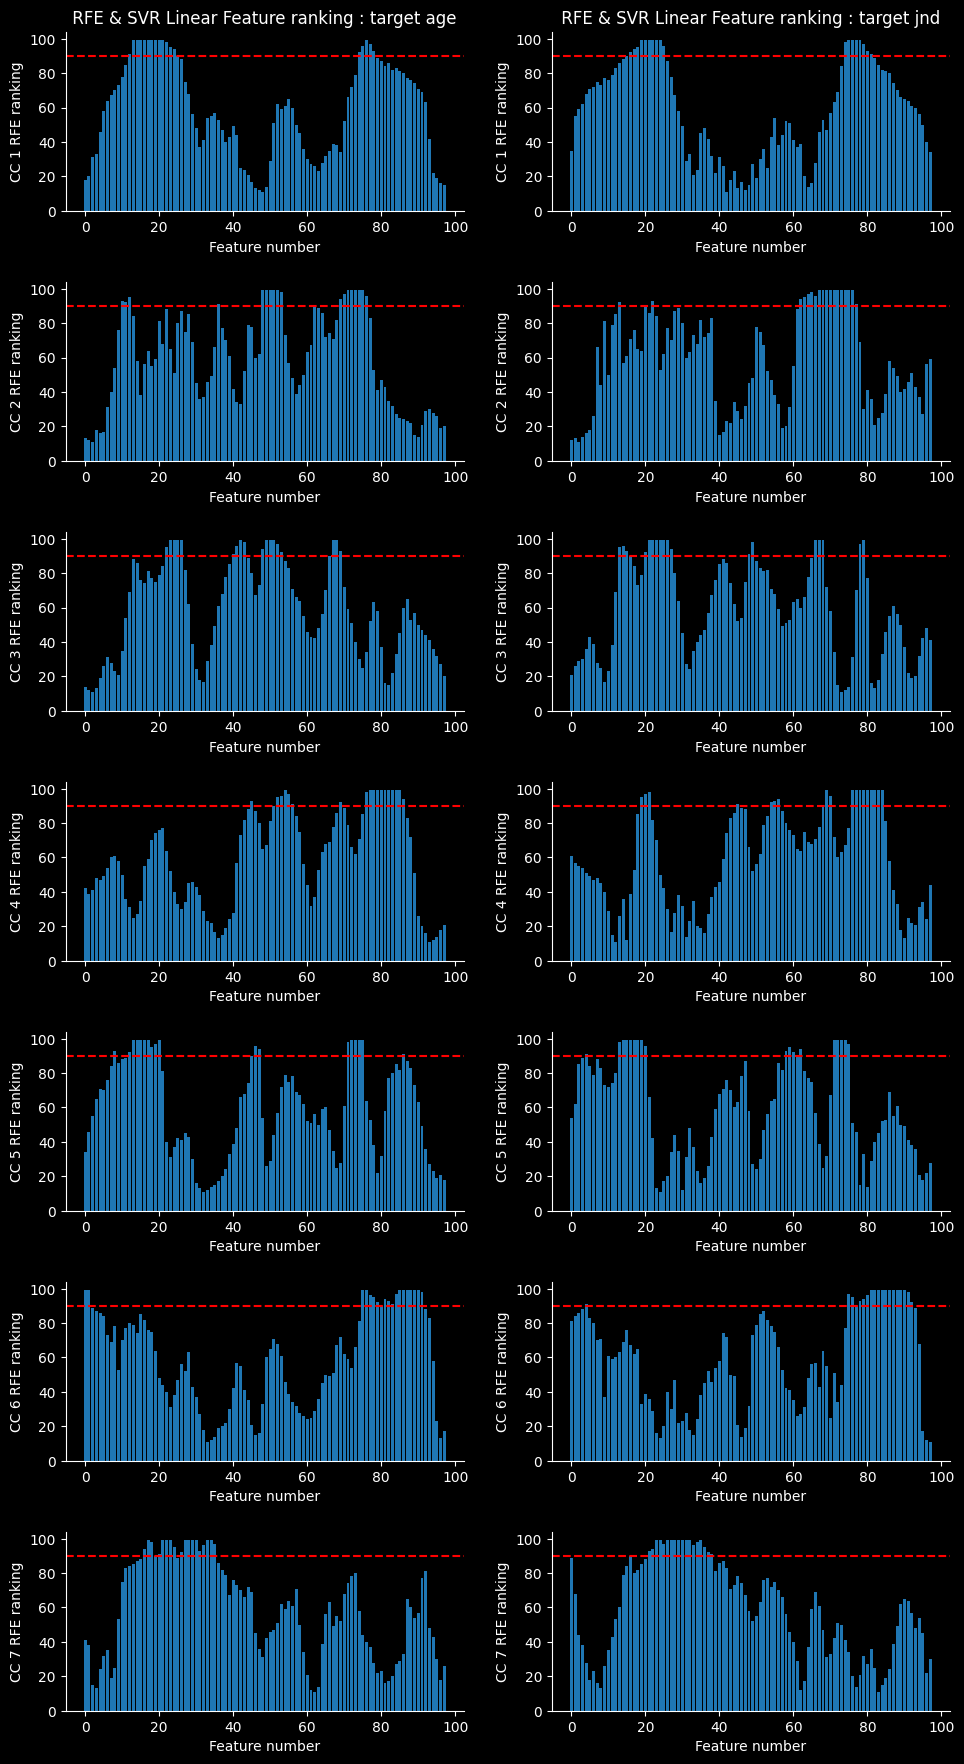

In [14]:
from sklearn.datasets import make_friedman1
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression

target=['age', 'jnd']
figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(10, 18))

ranked_feat_allCC_tgt=[]

for t in target:
    if t=='age':
        y=age
        axsy=0
    elif t=='jnd':
        y=jnd
        axsy=1
    ranked_feat_allCC=[]
    
    for cc in range(7):

        X=DTI[:,:,cc]     # Features (independent variable)
            
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        estimator = SVR(kernel="linear")
        estimator2=LogisticRegression()
        
        selector = RFE(estimator, n_features_to_select=10, step=1)
        selector = selector.fit(X_train, y_train)
        selector.support_
        selector.ranking_
        ranked_feat_allCC.append(selector.ranking_)

        np.where(selector.ranking_<10)[0].tolist()
        axs[cc, axsy].bar(np.arange(98), 100-selector.ranking_)
        axs[cc, axsy].axhline(90, color='red', linestyle='--')  
        axs[cc, axsy].set_xlabel("Feature number")
        axs[cc, axsy].set_ylabel(f'CC {cc+1} RFE ranking') 
        axs[cc, axsy].spines['top'].set_visible(False)
        axs[cc, axsy].spines['right'].set_visible(False)

    axs[0, axsy].set_title(f' RFE & SVR Linear Feature ranking : target {t} ')
    plt.tight_layout(pad=2.0)


    ranked_feat_allCC_tgt.append(ranked_feat_allCC)



Random state: 61
MAE: 2.194684601559144
MAE: 3.505439406258547
MAE: 4.012872228281628
MAE: 2.5269416213357365
MAE: 2.3461150657969907
MAE: 2.633306714781206
MAE: 3.655972614329998


array([ 3.48,  5.21,  3.04, 14.86, 10.87])

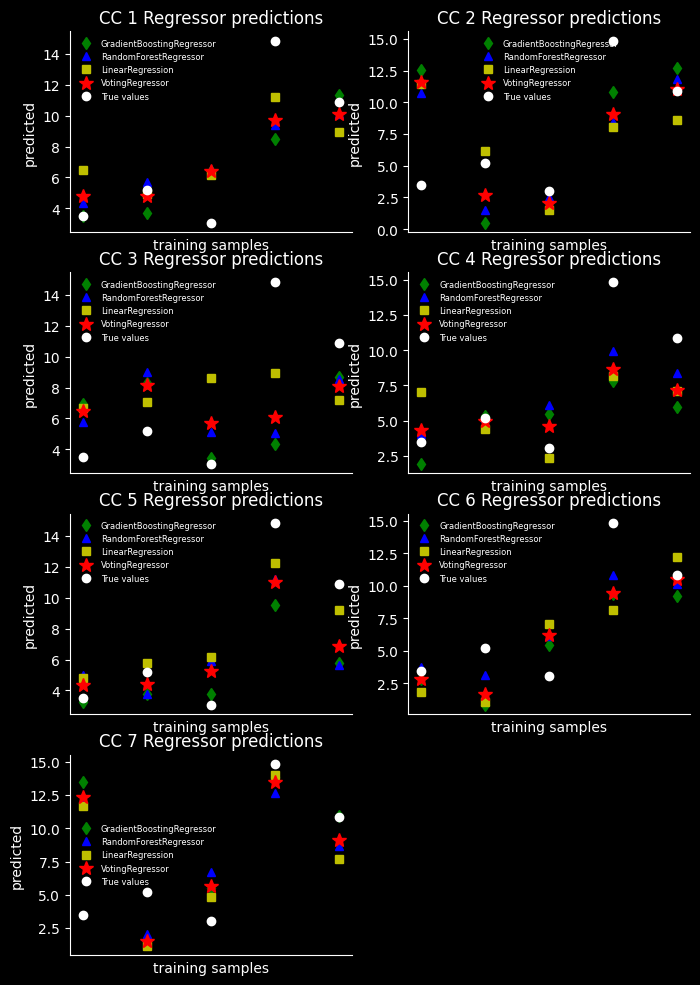

In [15]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

featSelectedOn='age'
target='jnd'

if target=='age':
    y=age       # Features (independent variable)
elif target=='jnd':
    y=jnd       # Features (independent variable)

if featSelectedOn=='age':
    SelectedFeat=ranked_feat_allCC_tgt[0]
elif featSelectedOn=='jnd':
    SelectedFeat=ranked_feat_allCC_tgt[1]

figure, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 12)
                           )

axs = axs.flatten()
random_state=np.random.randint(0,100)
print("Random state:", random_state)
for cc in range(0,7):
    select_feature=np.where(SelectedFeat[cc]==1)

    X=DTI[:,select_feature[0].tolist(),cc]    
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
         # Target (dependent variable)
# Train classifiers
    reg1 = GradientBoostingRegressor(random_state=1)
    reg2 = RandomForestRegressor(random_state=1)
    reg3 = LinearRegression()


    reg1.fit(X_train_scaled, y_train)
    reg2.fit(X_train_scaled, y_train)
    reg3.fit(X_train_scaled, y_train)

    ereg = VotingRegressor([("gb", reg1), ("rf", reg2), ("lr", reg3)])
    ereg.fit(X_train_scaled, y_train)


    pred1 = reg1.predict(X_test_scaled)
    pred2 = reg2.predict(X_test_scaled)
    pred3 = reg3.predict(X_test_scaled)
    pred4 = ereg.predict(X_test_scaled)
    # print("r2_score:", r2_score(y_test, pred4))
    print("MAE:", mean_absolute_error(y_test, pred4))
    axs[cc].plot(pred1, "gd", label="GradientBoostingRegressor")
    axs[cc].plot(pred2, "b^", label="RandomForestRegressor")
    axs[cc].plot(pred3, "ys", label="LinearRegression")
    axs[cc].plot(pred4, "r*", ms=10, label="VotingRegressor")
    axs[cc].plot(y_test, "wo", label="True values")
    axs[cc].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axs[cc].set_ylabel("predicted")
    axs[cc].set_xlabel("training samples")
    axs[cc].legend(loc="best", fontsize=6, frameon=False)
    axs[cc].set_title(f"CC {cc+1} Regressor predictions")
    axs[cc].spines['top'].set_visible(False)
    axs[cc].spines['right'].set_visible(False)

axs[7].axis('off')
y_test

In [22]:
select_feature

(array([23, 24, 26, 27, 28, 29, 30, 31, 32, 35]),)

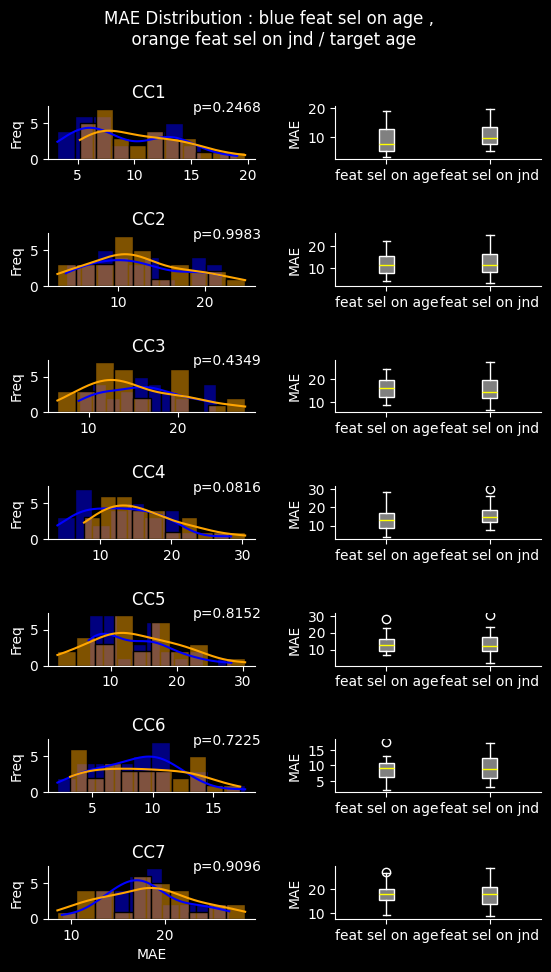

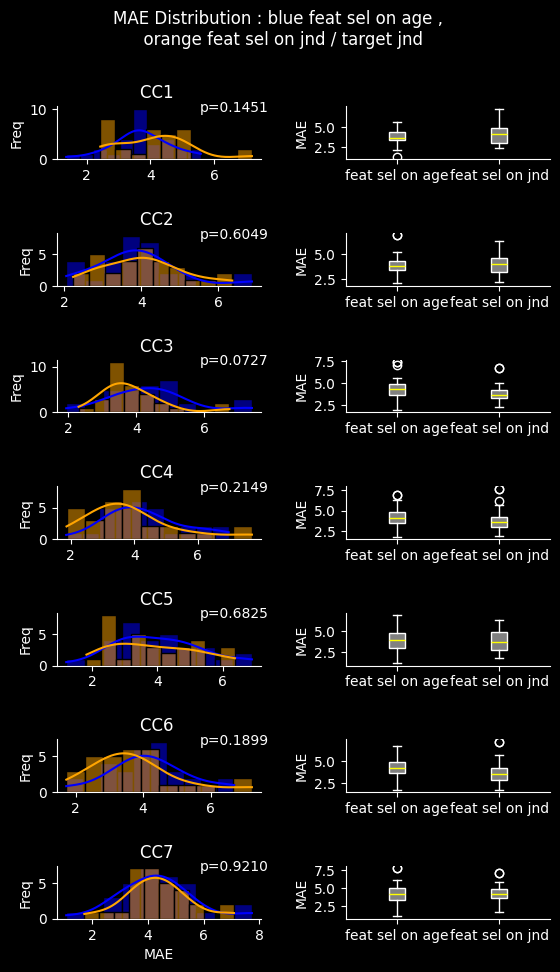

In [94]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind


nseeds=30
random_numbers = [random.randint(0, 100) for _ in range(nseeds)]

for target in ['age', 'jnd']:

    MAE_cc_all_alltgt=[]
    R_squareds_cc_all_alltgt=[]
    MSE_cc_all_alltgt=[]

    if target=='age':
        y=age       
    elif target=='jnd':
        y=jnd       

    for featSelectedOn in ['age','jnd']:

        if featSelectedOn=='age':
            SelectedFeat=ranked_feat_allCC_tgt[0]
        elif featSelectedOn=='jnd':
            SelectedFeat=ranked_feat_allCC_tgt[1]
                            
        MAE_cc_all=[]
        R_squareds_cc_all=[]
        MSE_cc_all=[]

        for cc in range(0,7):
            MAE_cc=[]
            R_squareds_cc=[]
            MSE_cc=[]
            for seed in range(nseeds):
                random_state=random_numbers[seed]
                select_feature=np.where(SelectedFeat[cc]<5)

                X=DTI[:,select_feature[0].tolist(),cc]    

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                    # Target (dependent variable)
            # Train classifiers
                reg1 = GradientBoostingRegressor(random_state=1)
                reg2 = RandomForestRegressor(random_state=1)

                if target=='age':
                    reg3 = LinearRegression()
                elif target=='jnd':
                    reg3 = LinearRegression()

                reg1.fit(X_train_scaled, y_train)
                reg2.fit(X_train_scaled, y_train)
                reg3.fit(X_train_scaled, y_train)

                ereg = VotingRegressor([("gb", reg1), ("rf", reg2), ("lr", reg3)])
                ereg.fit(X_train_scaled, y_train)

                pred1 = reg1.predict(X_test_scaled)
                pred2 = reg2.predict(X_test_scaled)
                pred3 = reg3.predict(X_test_scaled)
                pred4 = ereg.predict(X_test_scaled)
                # print("r2_score:", r2_score(y_test, pred4))
                MAE_cc.append(mean_absolute_error(y_test, pred4))
                R_squareds_cc.append(r2_score(y_test, pred4))
                MSE_cc.append(mean_squared_error(y_test, pred4))

                # print("MAE:", mean_absolute_error(y_test, pred4))

            MAE_cc_all.append(MAE_cc)
            R_squareds_cc_all.append(R_squareds_cc)
            MSE_cc_all.append(MSE_cc)

        MAE_cc_all_alltgt.append(MAE_cc_all)
        R_squareds_cc_all_alltgt.append(R_squareds_cc_all)
        MSE_cc_all_alltgt.append(MSE_cc_all)

    #####

    fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(6, 10))
    MAE_cc_all_alltgt[0][cc]


    for cc in range(7):
        t_stat, p_value = ttest_ind(MAE_cc_all_alltgt[0][cc], MAE_cc_all_alltgt[1][cc])
        sns.histplot(MAE_cc_all_alltgt[0][cc], bins=10, kde=True, color='blue',ax=ax[cc,0])
        sns.histplot(MAE_cc_all_alltgt[1][cc], bins=10, kde=True, color='orange',ax=ax[cc,0])
        ax[cc,0].text(0.7, 0.9, f'p={p_value:.4f}', transform=ax[cc,0].transAxes, color='white')
        ax[cc,0].set_title(f'CC{cc+1} ')    
        ax[cc,0].set_ylabel('Freq')
        ax[cc,0].grid(False)
        ax[cc,0].spines['top'].set_visible(False)
        ax[cc,0].spines['right'].set_visible(False)


        ax[cc,1].boxplot([MAE_cc_all_alltgt[0][cc], MAE_cc_all_alltgt[1][cc]], labels=['feat sel on age', 'feat sel on jnd'], patch_artist=True,
                       boxprops=dict(facecolor='grey', color='white'),
                       medianprops=dict(color='yellow'),
                       whiskerprops=dict(color='white'),
                       capprops=dict(color='white'),
                       flierprops=dict(color='white', markeredgecolor='white'))
        ax[cc,1].set_ylabel('MAE')
        ax[cc,1].grid(False)
        ax[cc,1].spines['top'].set_visible(False)
        ax[cc,1].spines['right'].set_visible(False)


    ax[6,0].set_xlabel('MAE')
    fig.suptitle('MAE Distribution : blue feat sel on age ,\n  orange feat sel on jnd / target '+target)
    plt.tight_layout(pad=2.0 )
    plt.show()

In [89]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind


nseeds=10

random_numbers = [random.randint(0, 100) for _ in range(nseeds)]

######################################""
# for target in ['age', 'jnd']:
target='jnd'


MAE_cc_all_alltgt=[]
R_squareds_cc_all_alltgt=[]
MSE_cc_all_alltgt=[]

if target=='age':
    y=age       
elif target=='jnd':
    y=jnd       

##########################
# for featSelectedOn in ['age','jnd']: 
featSelectedOn='jnd'

if featSelectedOn=='age':
    SelectedFeat=ranked_feat_allCC_tgt[0]
elif featSelectedOn=='jnd':
    SelectedFeat=ranked_feat_allCC_tgt[1]

  ##########################
    # for cc in range(0,7):

Ranking_feat=[2,5,10,15,20,25,30]


MAE_cc_all_allcc=[]

for cc in range(0,7):

    MAE_cc_all=[]
    R_squareds_cc_all=[]
    MSE_cc_all=[]

    for nfeatRanked in Ranking_feat:

        MAE_cc=[]
        R_squareds_cc=[]
        MSE_cc=[]
        for seed in range(nseeds):
            random_state=random_numbers[seed]
            select_feature=np.where(SelectedFeat[cc]<nfeatRanked)

            X=DTI[:,select_feature[0].tolist(),cc]    

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
                # Target (dependent variable)
        # Train classifiers
            reg1 = GradientBoostingRegressor(random_state=1)
            reg2 = RandomForestRegressor(random_state=1)

            if target=='age':
                reg3 = LinearRegression()
            elif target=='jnd':
                reg3 = LinearRegression()

            reg1.fit(X_train_scaled, y_train)
            reg2.fit(X_train_scaled, y_train)
            reg3.fit(X_train_scaled, y_train)

            ereg = VotingRegressor([("gb", reg1), ("rf", reg2), ("lr", reg3)])
            ereg.fit(X_train_scaled, y_train)

            pred1 = reg1.predict(X_test_scaled)
            pred2 = reg2.predict(X_test_scaled)
            pred3 = reg3.predict(X_test_scaled)
            pred4 = ereg.predict(X_test_scaled)
            # print("r2_score:", r2_score(y_test, pred4))
            MAE_cc.append(mean_absolute_error(y_test, pred4))
            R_squareds_cc.append(r2_score(y_test, pred4))
            MSE_cc.append(mean_squared_error(y_test, pred4))


        MAE_cc_all.append(MAE_cc)
        R_squareds_cc_all.append(R_squareds_cc)
        MSE_cc_all.append(MSE_cc)

    MAE_cc_all_allcc.append(MAE_cc_all)


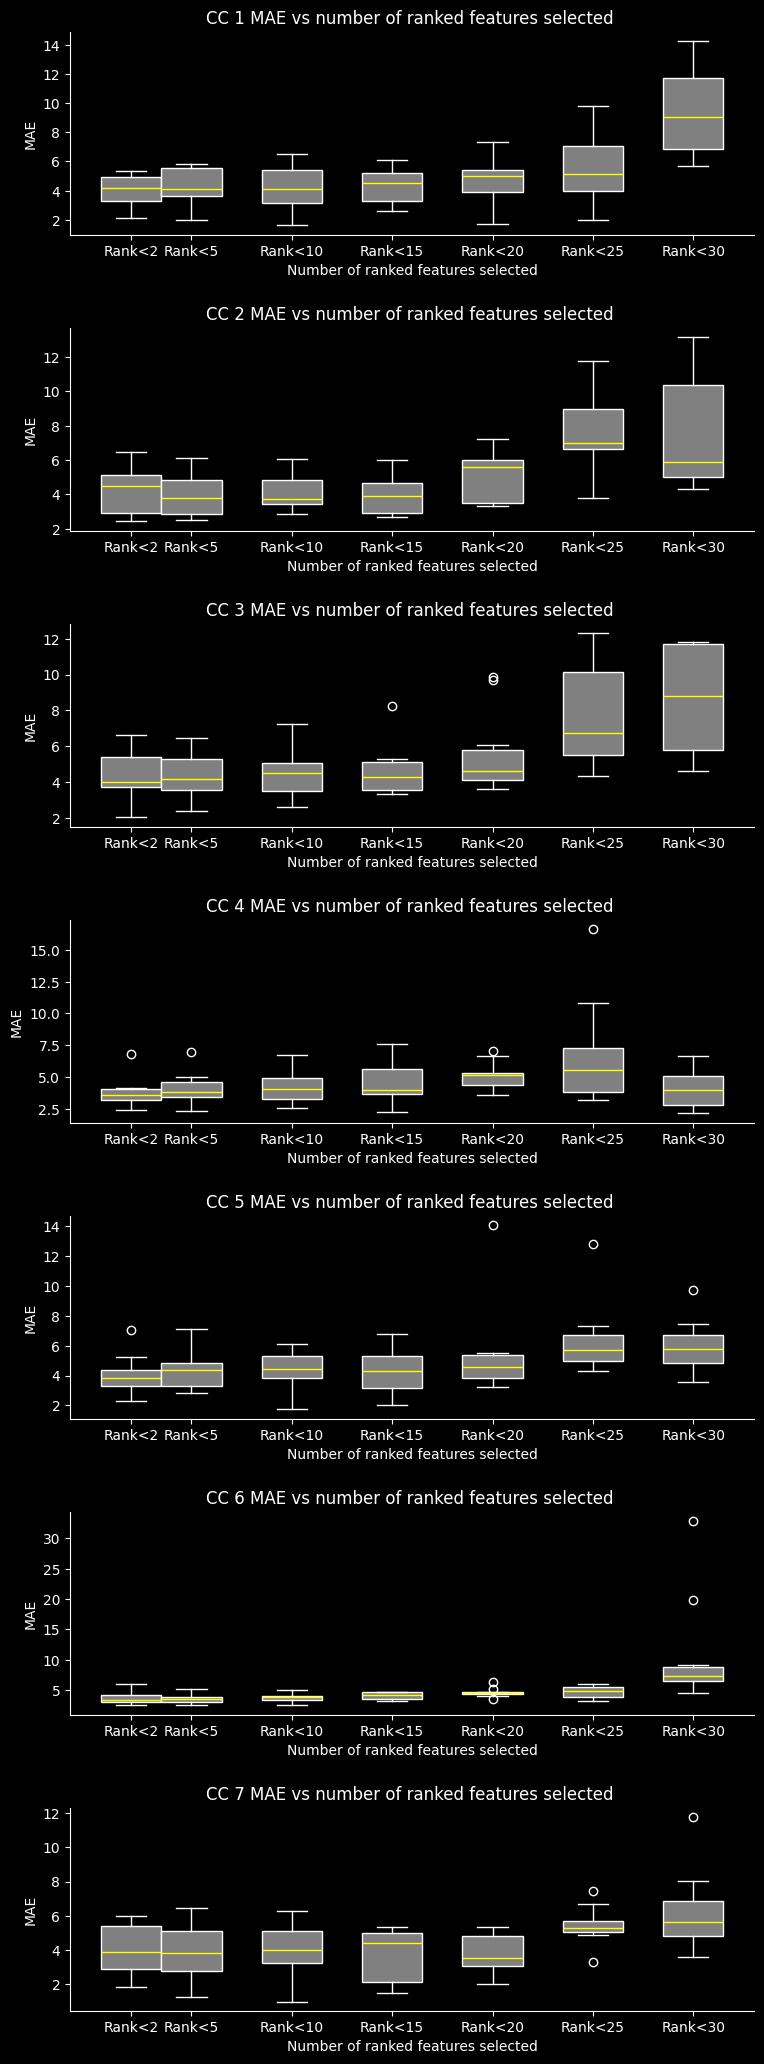

In [93]:
fig, ax = plt.subplots(nrows=7, ncols=1,figsize=(8,21))
for cc in range(7):
    ax[cc].boxplot(MAE_cc_all_allcc[cc], labels=[f'Rank<{n}' for n in Ranking_feat],positions=Ranking_feat, widths=3, patch_artist=True,
                   boxprops=dict(facecolor='grey', color='white'),
                   medianprops=dict(color='yellow'),
                   whiskerprops=dict(color='white'),
                   capprops=dict(color='white'),
                   flierprops=dict(color='white', markeredgecolor='white'))

    ax[cc].set_title(f'CC {cc+1} MAE vs number of ranked features selected ')
    ax[cc].set_xlabel('Number of ranked features selected')
    ax[cc].set_ylabel('MAE')
    ax[cc].grid(False)
    ax[cc].spines['top'].set_visible(False)
    ax[cc].spines['right'].set_visible(False)

ax[0].set_title(f'CC 1 MAE vs number of ranked features selected ')
ax[0].set_xlabel('Number of ranked features selected')
ax[0].set_ylabel('MAE')
ax[0].grid(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
plt.tight_layout(pad=2.0 )

ValueError: Dimensions of labels and X must be compatible

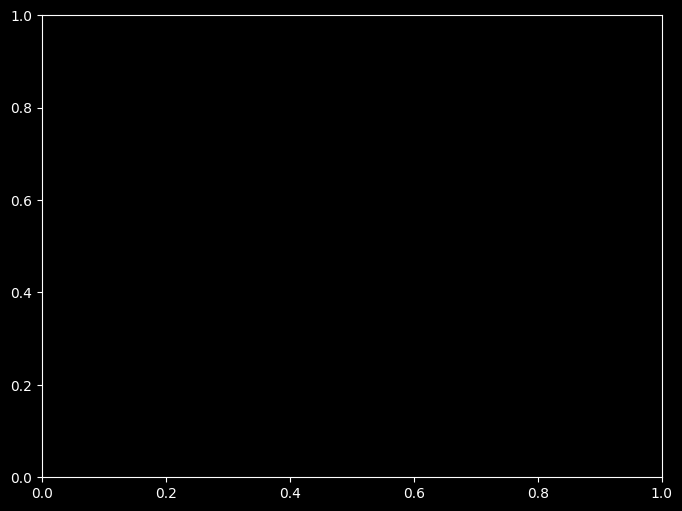

In [91]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(MAE_cc_all[0], labels=[f'Rank<{n}' for n in Ranking_feat], patch_artist=True,
                boxprops=dict(facecolor='grey', color='white'),
                medianprops=dict(color='yellow'),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(color='white', markeredgecolor='white'))
plt.show()
